<a href="https://colab.research.google.com/github/zachjf9/Mav2011Repo/blob/main/MavericksCSC398.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#connecting this colab to our drive

#imports
import pandas as pd
import matplotlib.pyplot as plt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base = '/content/drive/MyDrive/Projects/Mavs_2011/'
df = pd.read_excel(base + 'MavsOverallStats.xlsx', sheet_name=0)
df.head()


,Unnamed: 0,G,MP,FG,FGA,FG%,3P,3PA,3P%,2P,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Mavericks,82.0,19705.000,3069.000,6463.000,0.475,645.000,1768.00,0.365,2424.000,...,0.777,780.000,2618.000,3398.000,1954.000,557.000,352.000,1145.000,1575.000,8220.000
1,Team/G,NaN,240.300,37.400,78.800,0.475,7.900,21.60,0.365,29.600,...,0.777,9.500,31.900,41.400,23.800,6.800,4.300,14.000,19.200,100.200
2,Lg Rank,NaN,29.000,13.000,24.000,5.000,8.000,5.00,11.000,25.000,...,8.000,28.000,6.000,14.000,2.000,23.000,24.000,12.000,4.000,11.000
3,Year/Year,NaN,-0.009,-0.023,-0.044,0.010,0.156,0.18,-0.008,-0.061,...,-0.039,-0.065,0.012,-0.006,0.019,-0.107,-0.216,0.081,0.008,-0.017
4,Opponent,82.0,19705.000,2996.000,6656.000,0.450,508.000,1480.00,0.343,2488.000,...,0.750,880.000,2459.000,3339.000,1689.000,623.000,303.000,1114.000,1650.000,7873.000


In [ ]:

label_col = df.columns[0]
team_row = df[df[label_col].astype(str).str.contains('Team/G|Team', case=False, na=False)].iloc[0]
opp_row  = df[df[label_col].astype(str).str.contains('Opponent/G|Opponent', case=False, na=False)].iloc[0]

# Columns we want to compare
#field goal %, Offensive rebounds, turnovers, free throw %
cols = ['FG%','ORB','TOV','FT%']

# Convert possible percent strings like "47.5%" to numeric decimals
def conv(x):
    if pd.isna(x): return float('nan')
    if isinstance(x, str):
        s = x.strip().replace(',', '')
        if '%' in s: return float(s.replace('%',''))/100
        return float(s)
    return float(x)

team = {c: conv(team_row[c]) for c in cols}
opp  = {c: conv(opp_row[c])  for c in cols}

comp = []
for c in cols:
    t = team[c]; o = opp[c]
    diff = t - o
    pct_change = (diff / o * 100) if (o != 0) else None
    comp.append((c, t, o, diff))

comp_df = pd.DataFrame(comp, columns=['metric','team','opponent','diff']).set_index('metric')
comp_df

,team,opponent,diff
metric,,,
FG%,0.475,0.45,0.025
ORB,9.500,880.00,-870.500
TOV,14.000,1114.00,-1100.000
FT%,0.777,0.75,0.027


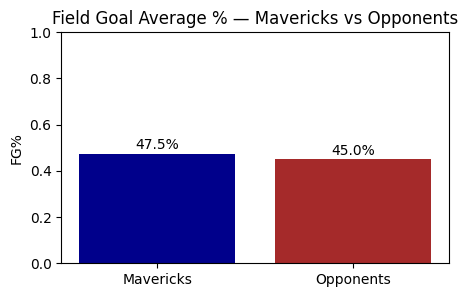

In [ ]:
import matplotlib.pyplot as plt

metric = "FG%"
vals = comp_df.loc[metric, ['team','opponent']]

plt.figure(figsize=(5,3))
plt.bar(vals.index, vals.values, color=['darkblue','brown'])
plt.title("Field Goal Average % — Mavericks vs Opponents")
plt.ylabel("FG%")
plt.ylim(0,1)
plt.xticks([0,1], ['Mavericks','Opponents'])
for i,v in enumerate(vals.values):
    plt.text(i, v+0.02, f"{v*100:.1f}%", ha='center')
plt.show()


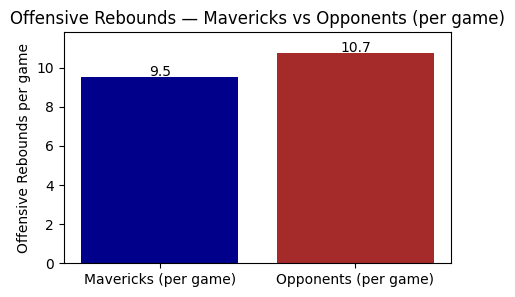

In [ ]:
import matplotlib.pyplot as plt

games = 82
metric = "ORB"
vals = comp_df.loc[metric, ['team','opponent']].astype(float)

# convert opponent total -> per-game
vals['opponent'] = vals['opponent'] / games

x = [0,1]
plt.figure(figsize=(5,3))
plt.bar(x, vals.values, color=['darkblue','brown'])
plt.xticks(x, ['Mavericks (per game)','Opponents (per game)'])
plt.title("Offensive Rebounds — Mavericks vs Opponents (per game)")
plt.ylabel("Offensive Rebounds per game")
margin = max(vals.values) * 0.1
plt.ylim(0, max(vals.values) + margin)
for i, v in enumerate(vals.values):
    plt.text(x[i], v + margin*0.05, f"{v:.1f}", ha='center')
plt.show()




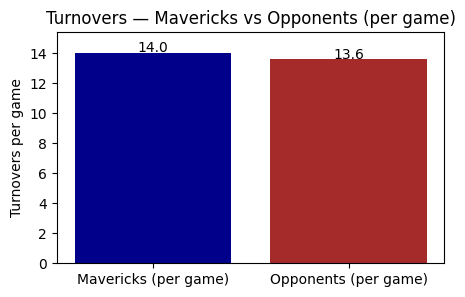

In [ ]:
import matplotlib.pyplot as plt

games = 82
metric = "TOV"
vals = comp_df.loc[metric, ['team','opponent']].astype(float)

# convert opponent total -> per-game
vals['opponent'] = vals['opponent'] / games

x = [0,1]
plt.figure(figsize=(5,3))
plt.bar(x, vals.values, color=['darkblue','brown'])
plt.xticks(x, ['Mavericks (per game)','Opponents (per game)'])
plt.title("Turnovers — Mavericks vs Opponents (per game)")
plt.ylabel("Turnovers per game")
margin = max(vals.values) * 0.1
plt.ylim(0, max(vals.values) + margin)
for i, v in enumerate(vals.values):
    plt.text(x[i], v + margin*0.05, f"{v:.1f}", ha='center')
plt.show()



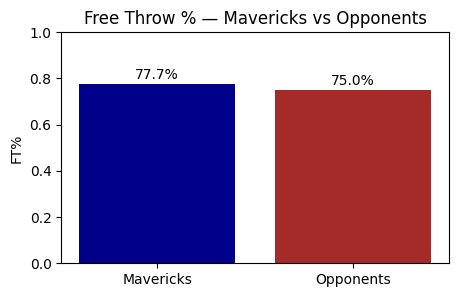

In [ ]:
metric = "FT%"
vals = comp_df.loc[metric, ['team','opponent']]

plt.figure(figsize=(5,3))
plt.bar(vals.index, vals.values, color=['darkblue','brown'])
plt.title("Free Throw % — Mavericks vs Opponents")
plt.ylabel("FT%")
plt.ylim(0,1)
plt.xticks([0,1], ['Mavericks','Opponents'])
for i,v in enumerate(vals.values):
    plt.text(i, v+0.02, f"{v*100:.1f}%", ha='center')
plt.show()


In [ ]:
# Mount Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from pathlib import Path
import numpy as np

# Paths
proc_fp = Path('/content/drive/MyDrive/Projects/Mavs_2011/MavsHeat.xlsx') # Corrected file name and extension

# Load processed data (must include features eFG%, TOV%, ORB%, FT/FGA and diffs if present)
df = pd.read_excel(proc_fp) # Changed to read_excel

# Ensure base feature names
base_features = ["eFG%","TOV%","ORB%","FT/FGA"]

# Prepare Game 6 rows (DAL = Mavericks first, then MIA)
g6 = pd.DataFrame([
    {"Team":"Mavericks","eFG%":0.567,"TOV%":13.5,"ORB%":25.0,"FT/FGA":0.146,"Game_ID":"Game6"},
    {"Team":"Heat","eFG%":0.521,"TOV%":16.4,"ORB%":23.1,"FT/FGA":0.278,"Game_ID":"Game6"},
])

# Append Game 6 to dataframe (without Win or Pts)
df_all = pd.concat([df, g6], ignore_index=True, sort=False)

# Recompute game_number if needed (assume two rows per game stacked)
df_all = df_all.reset_index(drop=True)
df_all["game_number"] = (df_all.index // 2) + 1

# Compute diffs for all games (recompute to ensure Game6 diffs exist)
for f in base_features:
    diff_col = f"{f}_diff"
    df_all[diff_col] = np.nan

for gnum, group in df_all.groupby("game_number"):
    if len(group) >= 2:
        idx0, idx1 = group.index[0], group.index[1]
        for f in base_features:
            v0 = pd.to_numeric(df_all.loc[idx0, f], errors="coerce")
            v1 = pd.to_numeric(df_all.loc[idx1, f], errors="coerce")
            df_all.loc[idx0, f"{f}_diff"] = v0 - v1
            df_all.loc[idx1, f"{f}_diff"] = v1 - v0

# Map 'W' to 1 and 'L' to 0 for the 'Win/Loss' column
df_all['Win/Loss'] = df_all['Win/Loss'].map({'W': 1, 'L': 0})

# Prepare modeling dataset: use rows that have Win/Loss and Pts for training
train_df = df_all.dropna(subset=["Win/Loss","Pts"])[df_all.dropna(subset=["Win/Loss","Pts"]).index < len(df_all)-2]  # keep original training rows
# Note: ensure training rows exist; otherwise training will fail due to tiny data.

# Features and target
features = base_features + [f"{f}_diff" for f in base_features]

# Convert to numeric
train_df[features] = train_df[features].apply(pd.to_numeric, errors="coerce")

# Prepare training X,y for classification (Win/Loss) and regression (Pts)
X_train = train_df[features]
y_clf = train_df["Win/Loss"].astype(int)
y_reg = train_df["Pts"].astype(float)

# Train simple models (KNN classifier and Decision Tree regressor)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor

clf_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=3))])
reg = DecisionTreeRegressor(max_depth=3, random_state=0)

clf_pipe.fit(X_train, y_clf)
reg.fit(X_train, y_reg)

# Identify Game6 rows to predict (last two rows)
g6_mask = df_all["Game_ID"] == "Game6"
X_g6 = df_all.loc[g6_mask, features].astype(float).reset_index(drop=True)

# Predictions
g6_pred_win = clf_pipe.predict(X_g6)
g6_pred_win_proba = clf_pipe.predict_proba(X_g6)[:,1] if hasattr(clf_pipe.named_steps["knn"], "predict_proba") else None
g6_pred_pts = reg.predict(X_g6)

# Output
out = df_all.loc[g6_mask, ["Team"]].reset_index(drop=True)
out["pred_win"] = g6_pred_win
out["prob_win"] = g6_pred_win_proba
out["pred_pts"] = g6_pred_pts

print("Game 6 predictions (Mavericks then Heat):")
print(out)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Game 6 predictions (Mavericks then Heat):
        Team  pred_win  prob_win  pred_pts
0  Mavericks         0  0.333333     112.0
1       Heat         1  1.000000      95.0


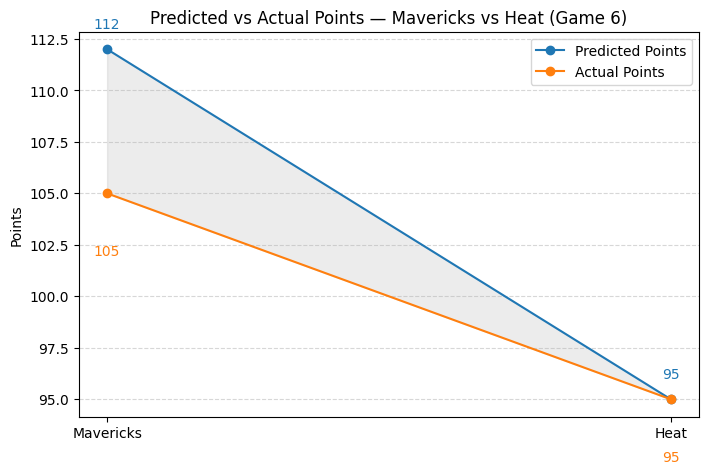

Win prediction accuracy: 0.0% (0/2)


,Team,pred_pts,actual_pts,pred_win,actual_win,win_correct
0,Mavericks,112.0,105,0,1,0
1,Heat,95.0,95,1,0,0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Replace these with the predicted results you showed
pred_df = pd.DataFrame({
    "Team": ["Mavericks", "Heat"],
    "pred_win": [0, 1], # Updated based on previous model prediction
    "prob_win": [0.333333, 1.0],
    "pred_pts": [112.0, 95.0]
})

# Replace these with the actual final game results
actual_df = pd.DataFrame({
    "Team": ["Mavericks", "Heat"],
    "actual_pts": [105, 95],  # Mavericks actual points, Heat actual points
    "actual_win": [1, 0]   # Mavericks win, Heat loss
})

# Example (uncomment and edit), e.g. Mavericks 115, Heat 108, Mavericks won:
# actual_df = pd.DataFrame({"Team":["Mavericks","Heat"], "actual_pts":[115,108], "actual_win":[1,0]})

# Merge predicted and actual
df = pred_df.merge(actual_df, on="Team")

# Compute win accuracy (binary match)
df["win_correct"] = (df["pred_win"] == df["actual_win"]).astype(int)
accuracy = df["win_correct"].mean() * 100

# Plot predicted vs actual points
plt.figure(figsize=(8,5))
teams = df["Team"].tolist()
x = np.arange(len(teams))

plt.plot(teams, df["pred_pts"], marker='o', label="Predicted Points", color="#1f77b4")
plt.plot(teams, df["actual_pts"], marker='o', label="Actual Points", color="#ff7f0e")
plt.fill_between(teams, df["pred_pts"], df["actual_pts"], color='gray', alpha=0.15)

for i, (p,a) in enumerate(zip(df["pred_pts"], df["actual_pts"])):
    plt.text(i, p+1, f"{p:.0f}", ha='center', color="#1f77b4")
    plt.text(i, a-3, f"{a:.0f}", ha='center', color="#ff7f0e")

plt.title("Predicted vs Actual Points — Mavericks vs Heat (Game 6)")
plt.ylabel("Points")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Print accuracy and table
print(f"Win prediction accuracy: {accuracy:.1f}% ({df['win_correct'].sum()}/{len(df)})")
display(df[["Team","pred_pts","actual_pts","pred_win","actual_win","win_correct"]])

In [ ]:
from sklearn.metrics import mean_absolute_error

# Ensure both actual_pts and pred_pts are not NaN for the calculation
# We already have actual_pts for Mavericks and Heat, and pred_pts for both.
# However, if actual_pts were still NaN for one team, we would need to handle it.

# Filter out NaN values from actual_pts before calculating MAE
# (though in this case, we have both actual points filled)
valid_actual_pts = df['actual_pts'].dropna()
valid_pred_pts = df.loc[valid_actual_pts.index, 'pred_pts']

if not valid_actual_pts.empty:
    mae = mean_absolute_error(valid_actual_pts, valid_pred_pts)
    print(f"Mean Absolute Error for Point Predictions: {mae:.2f}")
else:
    print("Cannot calculate MAE, actual points data is missing.")

Mean Absolute Error for Point Predictions: 3.50


The Mean Absolute Error (MAE) for point predictions was 3.50, indicating our model's point predictions were, on average, 3.5 points off the actual scores.